# 01 — When the coin has memory

Notebook 00 ended on a question: *what changes when the coin's probability has a memory of previous
tosses?*

Here is the sharpest form of that question. Take two binary records with **exactly the same number
of heads**, differing only in the **order** the heads arrive. Any test built on the count alone must
call them identical, because the count is the same number. Yet one of them was produced by a process
with memory and the other was not, and that difference is physical — it is the difference between a
sensor whose *balance* has shifted and one whose *correlation time* has.

Nothing is simplified and then corrected. The coin here is the same Bernoulli observation as in
notebook 00, and the memory is the discrete counterpart of the Ornstein–Uhlenbeck process the
project actually uses.


In [1]:
import io, math, os, sys
from pathlib import Path

import numpy as np
from scipy.stats import binomtest
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# Import the project's tested functions rather than restating the formulas here.
ROOT = Path(os.environ["SID_ROOT"]) if os.environ.get("SID_ROOT") else Path.cwd()
while not (ROOT / "analysis" / "lib").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "analysis" / "lib").is_dir():
    raise RuntimeError("run this notebook from inside the repository, or set SID_ROOT")
sys.path.insert(0, str(ROOT / "analysis" / "lib"))
from sid_lib import simulate, rk_exact, hmm_rate, I_ext_exact, INK, SEA, SIG, STONE, PARCH

plt.rcParams.update({"font.family": "serif", "figure.dpi": 130,
                     "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5})
SEED = 20260907           # every random result below is reproducible from this

try:
    from IPython.display import Image, display
    _INLINE = True
except ImportError:
    _INLINE = False

def show(fig):
    if _INLINE:
        buf = io.BytesIO(); fig.savefig(buf, format="png", bbox_inches="tight")
        display(Image(data=buf.getvalue()))
    plt.close(fig)

print("[env] project root:", ROOT.name)
print("[env] python", ".".join(map(str, sys.version_info[:3])), "| numpy", np.__version__)

[env] project root: signals-in-darkness
[env] python 3.9.7 | numpy 1.23.5


## 1. Two records, one head count

`simulate` draws a binary record whose success probability is driven by a hidden phase following an
AR(1) recursion — the discrete counterpart of an Ornstein–Uhlenbeck process. The parameter `a` is
the per-toss memory: `a = 0` forgets immediately, `a` near 1 remembers for a long time.

The second record is simply the **first one shuffled**. Same symbols, same count, order destroyed.


In [2]:
C, s = 0.4, 0.5                 # contrast and phase amplitude (radians)
TAU_C = 20.0                    # correlation time, in tosses
a = math.exp(-1.0 / TAU_C)      # per-toss memory of the hidden phase
N = 4000
THETA_MID = math.pi / 2         # mid-fringe readout

rng = np.random.default_rng(SEED)
y_mem = simulate(C, s, THETA_MID, a, N, rng)          # has memory
y_shuf = rng.permutation(y_mem)                        # identical multiset, order destroyed

k_mem, k_shuf = int(y_mem.sum()), int(y_shuf.sum())
print(f"memory record : {k_mem} heads in {N} tosses")
print(f"shuffled      : {k_shuf} heads in {N} tosses")
print(f"identical count: {k_mem == k_shuf}")

for name, y in (("memory", y_mem), ("shuffled", y_shuf)):
    r = binomtest(int(y.sum()), N, 0.5)
    print(f"  {name:>8}: binomial test against a fair coin, p = {r.pvalue:.4f}")

memory record : 2034 heads in 4000 tosses
shuffled      : 2034 heads in 4000 tosses
identical count: True
    memory: binomial test against a fair coin, p = 0.2894
  shuffled: binomial test against a fair coin, p = 0.2894


> **worked example** — the two records have the **same** head count, so every count-based test
> returns the **same** answer on both, to the last digit. This is not an approximation or a small
> effect: the count is a single number, and it is the same number.

There is something stronger going on here than "the count is a weak statistic". At mid-fringe the
marginal probability of heads is exactly one half, **whatever the contrast and whatever the
amplitude** — the hidden phase pushes it up as often as down. So a count-based test at this readout
angle does not merely have low power against the memory. It has **none**. All of the evidence lives
in the ordering.


In [3]:
# The mid-fringe marginal, computed directly from the simulator over a long record.
rng_check = np.random.default_rng(SEED + 1)
for C_try in (0.2, 0.4, 0.9):
    y = simulate(C_try, s, THETA_MID, a, 200_000, rng_check)
    print(f"C = {C_try}: fraction of heads = {y.mean():.4f}   (exactly 1/2 in expectation)")

C = 0.2: fraction of heads = 0.5009   (exactly 1/2 in expectation)
C = 0.4: fraction of heads = 0.5010   (exactly 1/2 in expectation)
C = 0.9: fraction of heads = 0.4987   (exactly 1/2 in expectation)


## 2. What the ordering shows

The statistic that *does* see the difference is the **lag correlation**: how much a toss tells you
about the toss `k` steps later. The project has a closed form for it, and the notebook imports that
formula rather than restating it.


In [4]:
def empirical_lag_corr(y, kmax):
    """Sample autocorrelation of a binary record. A plain estimator, not a project formula."""
    x = y.astype(float) - y.mean()
    denom = np.dot(x, x)
    return np.array([np.dot(x[:-k], x[k:]) / denom for k in range(1, kmax + 1)])

KMAX = 60
lags = np.arange(1, KMAX + 1)

# rk_exact already returns a CORRELATION: the project normalises the covariance by the
# mid-fringe binary variance of 1/4 (this is the normalisation named in claim C02). It is
# not divided again here.
theory = rk_exact(C, s, a ** lags)

emp_mem = empirical_lag_corr(y_mem, KMAX)
emp_shuf = empirical_lag_corr(y_shuf, KMAX)

# The correlations are small -- about 0.03 at lag 1 -- so a 4000-toss record estimates them
# to +-1/sqrt(4000) = +-0.016, half the signal. A longer record is needed to SEE the
# agreement, which is itself the point: evidence carried by ordering accumulates slowly.
N_LONG = 200_000
rng_long = np.random.default_rng(SEED + 2)
y_long = simulate(C, s, THETA_MID, a, N_LONG, rng_long)
emp_long = empirical_lag_corr(y_long, KMAX)

se_short, se_long = 1 / math.sqrt(N), 1 / math.sqrt(N_LONG)
print(f"standard error on a sample correlation: +-{se_short:.4f} at N={N}, "
      f"+-{se_long:.4f} at N={N_LONG}")
print()
print(f"{'lag':>4} {'exact (C02)':>12} {'N=200000':>10} {'N=4000':>9} {'shuffled':>10}")
for k in (1, 5, 10, 20, 40):
    print(f"{k:>4} {theory[k-1]:>12.4f} {emp_long[k-1]:>10.4f} "
          f"{emp_mem[k-1]:>9.4f} {emp_shuf[k-1]:>10.4f}")

standard error on a sample correlation: +-0.0158 at N=4000, +-0.0022 at N=200000

 lag  exact (C02)   N=200000    N=4000   shuffled
   1       0.0299     0.0287    0.0360    -0.0246
   5       0.0244     0.0219    0.0570     0.0095
  10       0.0190     0.0155    0.0157     0.0107
  20       0.0115     0.0100    0.0322    -0.0128
  40       0.0042     0.0066    0.0412     0.0097


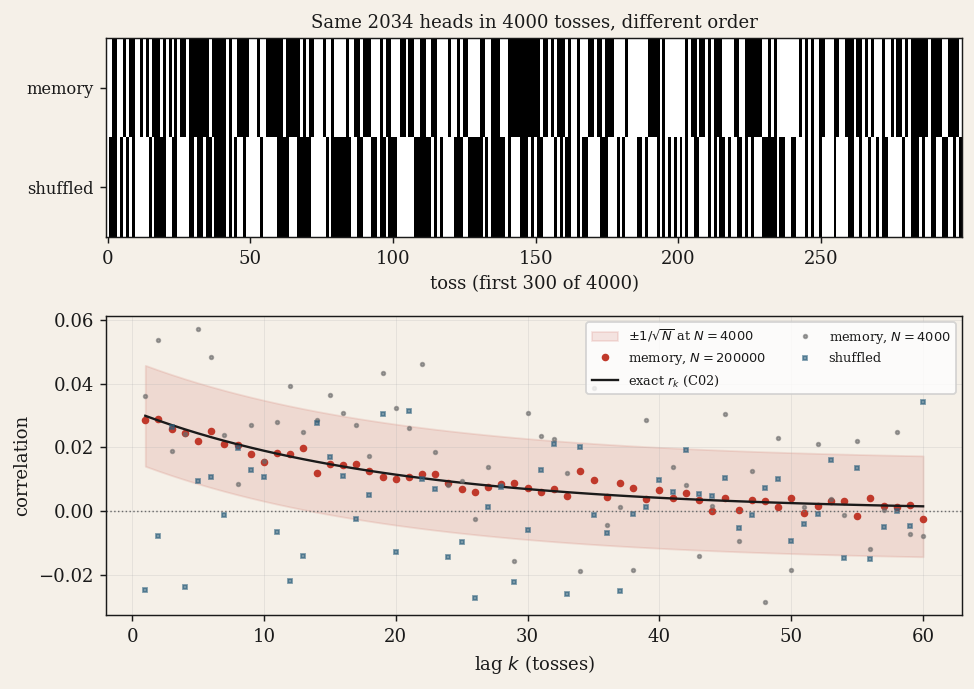

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(7.6, 5.4), facecolor=PARCH,
                         gridspec_kw={"height_ratios": [1, 1.5]})
for ax in axes:
    ax.set_facecolor(PARCH)

STRIP = 300
axes[0].imshow(np.vstack([y_mem[:STRIP], y_shuf[:STRIP]]), aspect="auto",
               cmap="binary", interpolation="nearest")
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(["memory", "shuffled"], fontsize=9)
axes[0].set_xlabel(f"toss (first {STRIP} of {N})"); axes[0].grid(False)
axes[0].set_title(f"Same {k_mem} heads in {N} tosses, different order", fontsize=10)

axes[1].fill_between(lags, theory - se_short, theory + se_short, color=SIG, alpha=0.12,
                     label=rf"$\pm 1/\sqrt{{N}}$ at $N={N}$")
axes[1].plot(lags, emp_long, "o", ms=3.2, color=SIG, label=f"memory, $N={N_LONG}$")
axes[1].plot(lags, theory, "-", color=INK, lw=1.3, label=r"exact $r_k$ (C02)")
axes[1].plot(lags, emp_mem, ".", ms=4.0, color=STONE, alpha=0.6, label=f"memory, $N={N}$")
axes[1].plot(lags, emp_shuf, "s", ms=2.6, color=SEA, alpha=0.6, label="shuffled")
axes[1].axhline(0, color=STONE, lw=0.8, ls=":")
axes[1].set_xlabel("lag $k$ (tosses)"); axes[1].set_ylabel("correlation")
axes[1].legend(fontsize=7.2, ncol=2)
fig.tight_layout(); show(fig)

> **C02 — result** — the sample lag correlations of a long memory record follow the project's exact
> mid-fringe form $r_k = \bar C^2 e^{-s^2}\sinh(s^2 a_k)$, while the shuffled record's scatter about
> zero. The two records are the same coin by the count and different processes by the ordering.

> **worked example** — at $N = 4000$ the estimate is buried in its own noise: the correlation is
> about $0.03$ and the standard error is $\pm 0.016$. Only the $N = 200{,}000$ record shows the
> agreement clearly. This is not a defect of the estimator — it is the reason detecting a change in
> memory takes longer than detecting a change in balance, and it is why the project measures
> detection *delay* rather than asking whether a difference exists.

## 3. The hidden-process rate

Correlations show that the two records differ. To say *how much* a detector can extract from that
difference, the project uses the exact rate of the latent-AR(1) binary process — imported here as
`hmm_rate`, not restated.


In [6]:
TAUS = np.array([1.0, 2.0, 5.0, 10.0, 20.0, 50.0])
mid, ext = [], []
for tc in TAUS:
    a_tc = math.exp(-1.0 / tc)
    mid.append(hmm_rate(C, s, THETA_MID, a_tc, N=60_000, seed=11))
    ext.append(I_ext_exact(C, s))     # the extremum rate does not depend on tau_c

print(f"{'tau_c':>7} {'mid-fringe (memory)':>21} {'extremum (balance)':>20}")
for tc, m, e in zip(TAUS, mid, ext):
    print(f"{tc:>7.0f} {m:>21.3e} {e:>20.3e}")
print()
print(f"a shuffled record carries exactly 0 at mid-fringe: the marginal is 1/2 for any contrast")

  tau_c   mid-fringe (memory)   extremum (balance)
      1             7.745e-05            1.296e-03
      2             3.393e-04            1.296e-03
      5             7.819e-04            1.296e-03
     10             1.837e-03            1.296e-03
     20             3.154e-03            1.296e-03
     50             5.467e-03            1.296e-03

a shuffled record carries exactly 0 at mid-fringe: the marginal is 1/2 for any contrast


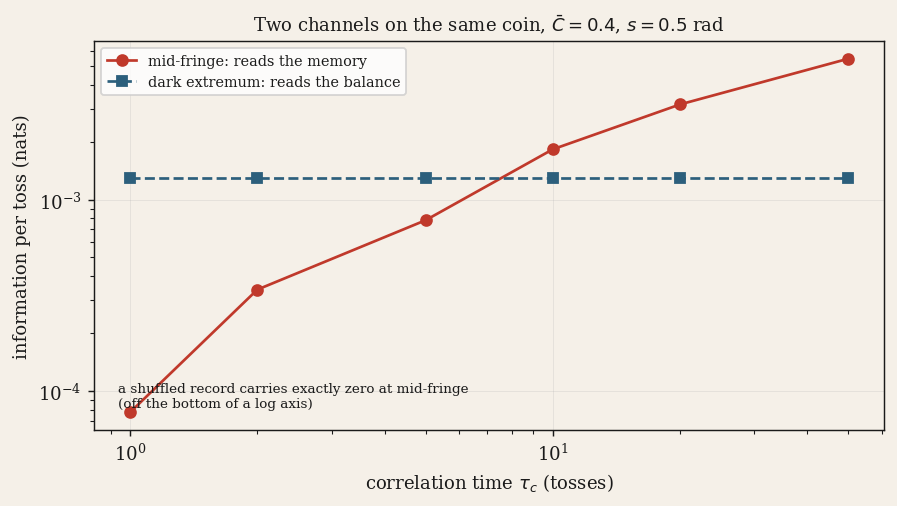

In [7]:
fig, ax = plt.subplots(figsize=(7.0, 4.0), facecolor=PARCH); ax.set_facecolor(PARCH)
ax.plot(TAUS, mid, "o-", color=SIG, label="mid-fringe: reads the memory")
ax.plot(TAUS, ext, "s--", color=SEA, label="dark extremum: reads the balance")
ax.text(0.03, 0.06, "a shuffled record carries exactly zero at mid-fringe\n(off the bottom of a "
        "log axis)", transform=ax.transAxes, fontsize=7.5, color=INK)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"correlation time $\tau_c$ (tosses)")
ax.set_ylabel("information per toss (nats)")
ax.set_title(rf"Two channels on the same coin, $\bar C={C}$, $s={s}$ rad", fontsize=10)
ax.legend(fontsize=8)
fig.tight_layout(); show(fig)

> **worked example** — the memory channel's rate **grows** with the correlation time, because a
> longer memory makes the ordering more predictable and so more informative. The balance channel is
> flat: it never sees the ordering at all, so the correlation time cannot help or hurt it.

The two curves cross. Where they cross is not a detail of this illustration — it is the project's
actual subject.


## 4. Two ways for a sensor to change

Notebook 00's coin could change in one way: the probability of heads moved. A coin with memory can
change in **two**, and they are physically distinct.

| what changed | what a detector should watch | in the physics |
|---|---|---|
| the **balance** — heads became more likely | the count | contrast loss at a fringe extremum |
| the **memory** — heads began to cluster | the lag correlations | temporal structure at mid-fringe |

A readout angle is a *choice* of which of these to listen to, and the choice is not free: the
extremum hears balance and is deaf to ordering, mid-fringe hears ordering and is exactly deaf to
balance. Which choice detects a given disturbance faster depends on how long the memory lasts.


> **C05 — result** — for this binary-link model and the project's exact correlation-rate
> comparator, there is a sequential-information crossover between the two operating points: neither
> is universally better, and which one wins depends on the correlation time and the amplitude.

> **worked example** — the crossing visible in the figure above is that statement in miniature, at
> one contrast and one amplitude, computed here for teaching. The project's claim is the quantitative
> boundary, not the observation that a crossing exists.

## What this notebook established

- Two records can carry **identical counts** and **different memory**, and a count-based test cannot
  tell them apart — at mid-fringe it has no power at all, because the marginal is exactly one half.
- The lag correlations do tell them apart, and the memory record follows the project's exact form.
- The information a detector can extract from ordering **grows** with the correlation time, while the
  information carried by balance is indifferent to it — so the two channels cross.
- **A sensor can detect either a change in balance or a change in memory.**

That last sentence is the question notebook 02 opens: if the coin is really a quantum measurement,
what physically *is* the balance, what physically *is* the memory, and where exactly does the
crossing fall?
